# EDA du prix Day-Ahead DE-LU

Cette analyse sert à comprendre la cible avant de choisir un modèle. Les prix jusqu'au 30 juin 2026 sont utilisés avant le test final ; juillet et août restent réservés au test.

## Charger les prix et fixer la frontière du test

Les calculs utilisent l'UTC. L'heure de Berlin sert à définir les journées de marché et les variables calendaires.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.day_ahead_price import de_lu_operational_feature_columns

MARKET_TIMEZONE = 'Europe/Berlin'
NATIVE_15M_START = pd.Timestamp('2025-10-01', tz=MARKET_TIMEZONE)
VALIDATION_START = pd.Timestamp('2026-05-01', tz=MARKET_TIMEZONE)
TEST_START = pd.Timestamp('2026-07-01', tz=MARKET_TIMEZONE)

prices = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'market_15m' / 'de_lu_day_ahead_prices.parquet'
)
prices['delivery_start_utc'] = pd.to_datetime(prices['delivery_start_utc'], utc=True)
prices['delivery_start_local'] = prices['delivery_start_utc'].dt.tz_convert(MARKET_TIMEZONE)

# Le test est compté mais ses prix ne sont pas utilisés pour choisir le modèle.
pre_test_prices = prices.loc[prices['delivery_start_local'] < TEST_START].copy()
native_prices = pre_test_prices.loc[pre_test_prices['is_native_15m_target']].copy()
old_hourly_prices = pre_test_prices.loc[~pre_test_prices['is_native_15m_target']].copy()

model_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'modeling' / 'de_lu_day_ahead_price_training_full.parquet'
)
model_data['delivery_start_utc'] = pd.to_datetime(model_data['delivery_start_utc'], utc=True)
model_data['delivery_start_local'] = model_data['delivery_start_utc'].dt.tz_convert(
    MARKET_TIMEZONE
)

## Vérifier la couverture et la qualité

Une journée normale contient 96 lignes. Le contrôle doit aussi accepter les journées de 92 ou 100 périodes lors des changements d'heure.

In [2]:
periods_per_day = prices.groupby('delivery_date_local').size()
time_differences = prices['delivery_start_utc'].diff().dropna()

quality_summary = pd.Series({
    'all_price_rows': len(prices),
    'pre_test_rows': len(pre_test_prices),
    'test_rows': len(prices) - len(pre_test_prices),
    'first_delivery': prices['delivery_start_local'].min(),
    'last_delivery': prices['delivery_start_local'].max(),
    'duplicate_timestamps': prices['delivery_start_utc'].duplicated().sum(),
    'missing_prices': prices['day_ahead_price'].isna().sum(),
    'non_15_minute_gaps': (time_differences != pd.Timedelta(minutes=15)).sum(),
    'days_with_92_periods': (periods_per_day == 92).sum(),
    'days_with_96_periods': (periods_per_day == 96).sum(),
    'days_with_100_periods': (periods_per_day == 100).sum(),
})
quality_summary.to_frame('value')

,value
all_price_rows,77664
pre_test_rows,71712
test_rows,5952
first_delivery,2024-06-14 00:00:00+02:00
last_delivery,2026-08-31 23:45:00+02:00
duplicate_timestamps,0
missing_prices,0
non_15_minute_gaps,0
days_with_92_periods,2
days_with_96_periods,805


La série de prix est continue et ne contient ni doublon ni valeur manquante. Les journées de 92 et 100 périodes sont conservées telles quelles.

## Distinguer l'ancien régime du vrai quart d'heure

Avant octobre 2025, SMARD place le même prix horaire sur quatre lignes. Après cette date, les quatre prix peuvent évoluer séparément.

In [3]:
def share_of_flat_hours(price_frame):
    prices_per_utc_hour = price_frame.groupby(
        price_frame['delivery_start_utc'].dt.floor('h')
    )['day_ahead_price'].nunique()
    return 100 * prices_per_utc_hour.eq(1).mean()

regime_summary = pd.DataFrame({
    'rows': [len(old_hourly_prices), len(native_prices)],
    'flat_hours_percent': [
        share_of_flat_hours(old_hourly_prices),
        share_of_flat_hours(native_prices),
    ],
}, index=['hourly_price_repeated', 'native_15m'])
regime_summary.round(2)

,rows,flat_hours_percent
hourly_price_repeated,45504,100.00
native_15m,26208,0.21


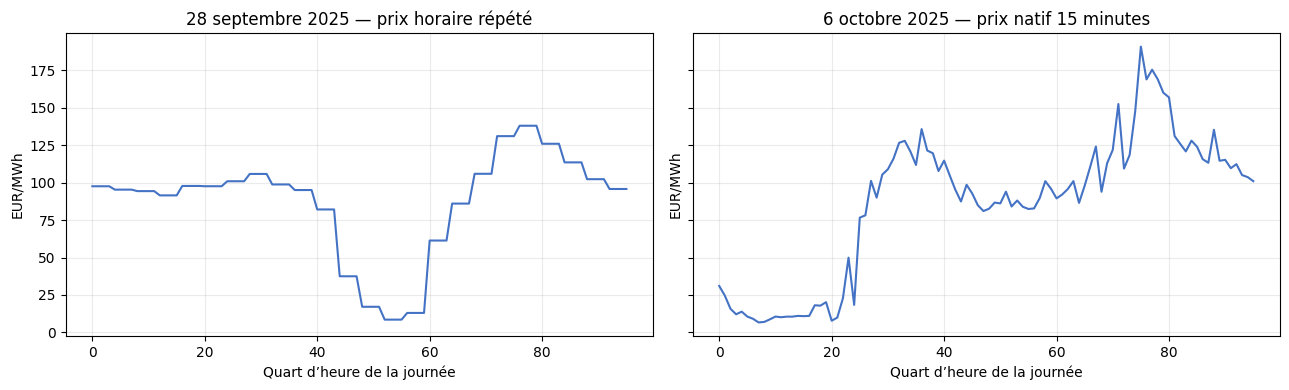

In [4]:
def select_local_day(price_frame, delivery_date):
    return price_frame.loc[
        price_frame['delivery_date_local'] == pd.Timestamp(delivery_date).date()
    ].reset_index(drop=True)

old_sample = select_local_day(pre_test_prices, '2025-09-28')
native_sample = select_local_day(pre_test_prices, '2025-10-06')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, sample, title in [
    (axes[0], old_sample, '28 septembre 2025 — prix horaire répété'),
    (axes[1], native_sample, '6 octobre 2025 — prix natif 15 minutes'),
]:
    axis.plot(sample.index, sample['day_ahead_price'], color='#4472C4')
    axis.set(title=title, xlabel='Quart d’heure de la journée', ylabel='EUR/MWh')
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Le premier profil avance par paliers de quatre points : il ne contient qu'une information indépendante par heure. Le second montre les variations infra-horaires que le modèle final doit apprendre. L'ancien historique pourra servir d'information complémentaire, avec un poids de `0,25` pendant l'entraînement.

## Niveau, prix négatifs et valeurs extrêmes

Les statistiques suivantes utilisent uniquement le régime natif disponible avant le test.

,EUR_per_MWh
count,26208.00
mean,96.81
std,57.38
min,-499.99
1%,-24.95
5%,-0.01
25%,77.51
50%,99.28
75%,123.02
95%,170.32


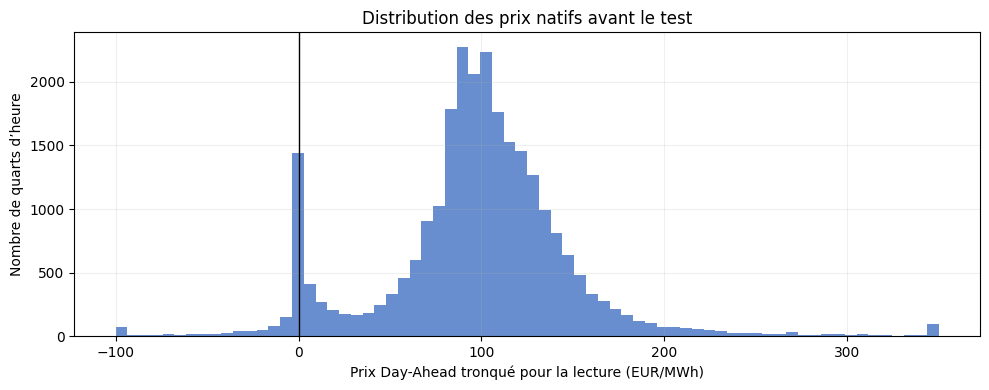

In [5]:
price_summary = native_prices['day_ahead_price'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).to_frame('EUR_per_MWh')
price_summary.loc['negative_price_share'] = native_prices['day_ahead_price'].lt(0).mean()
display(price_summary.round(2))

ax = native_prices['day_ahead_price'].clip(-100, 350).plot.hist(
    bins=70, figsize=(10, 4), color='#4472C4', alpha=0.8
)
ax.axvline(0, color='black', linewidth=1)
ax.set(
    title='Distribution des prix natifs avant le test',
    xlabel='Prix Day-Ahead tronqué pour la lecture (EUR/MWh)',
    ylabel='Nombre de quarts d’heure',
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

La distribution est asymétrique et comporte des épisodes extrêmes. Une erreur quadratique serait vite dominée par ces journées ; la MAE restera donc la métrique principale pour comparer les modèles.

## Saisonnalités mensuelle et infra-journalière

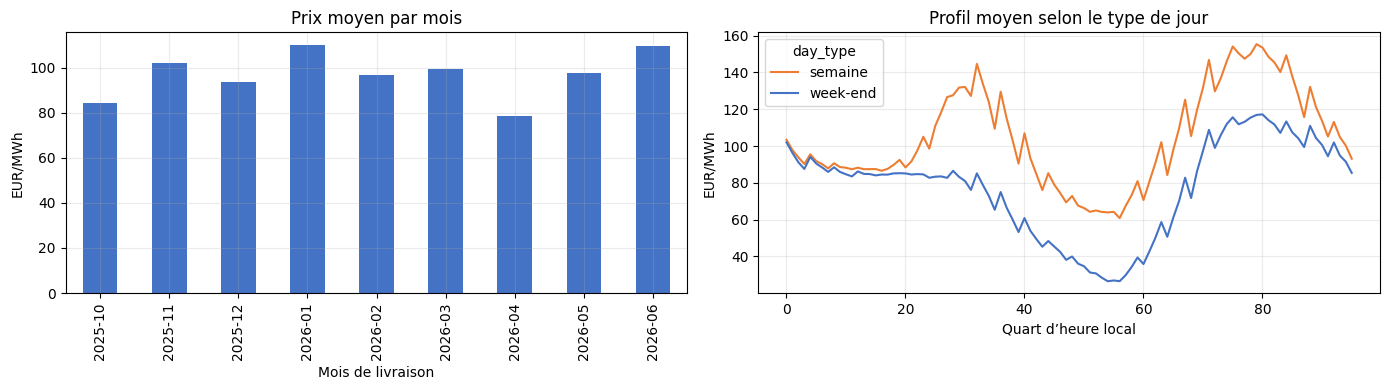

In [6]:
native_prices['delivery_month'] = native_prices['delivery_start_local'].dt.strftime('%Y-%m')
native_prices['local_quarter'] = (
    native_prices['delivery_start_local'].dt.hour * 4
    + native_prices['delivery_start_local'].dt.minute // 15
)
native_prices['day_type'] = native_prices['delivery_start_local'].dt.dayofweek.map(
    lambda weekday: 'week-end' if weekday >= 5 else 'semaine'
)

monthly_prices = native_prices.groupby('delivery_month')['day_ahead_price'].mean()
intraday_profile = native_prices.groupby(
    ['local_quarter', 'day_type']
)['day_ahead_price'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly_prices.plot.bar(ax=axes[0], color='#4472C4')
axes[0].set(title='Prix moyen par mois', xlabel='Mois de livraison', ylabel='EUR/MWh')
intraday_profile.plot(ax=axes[1], color=['#ED7D31', '#4472C4'])
axes[1].set(
    title='Profil moyen selon le type de jour',
    xlabel='Quart d’heure local',
    ylabel='EUR/MWh',
)
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Le niveau varie nettement d'un mois à l'autre et le profil journalier n'est pas plat. Le calendrier et l'heure locale ont donc une vraie utilité, mais ils ne suffiront pas à expliquer les pointes ou les prix négatifs.

## Variations d'un quart d'heure à l'autre

,absolute_15min_change_EUR_per_MWh
count,26207.00
mean,8.51
std,11.61
min,0.00
50%,4.82
90%,20.39
95%,28.93
99%,54.86
max,250.57


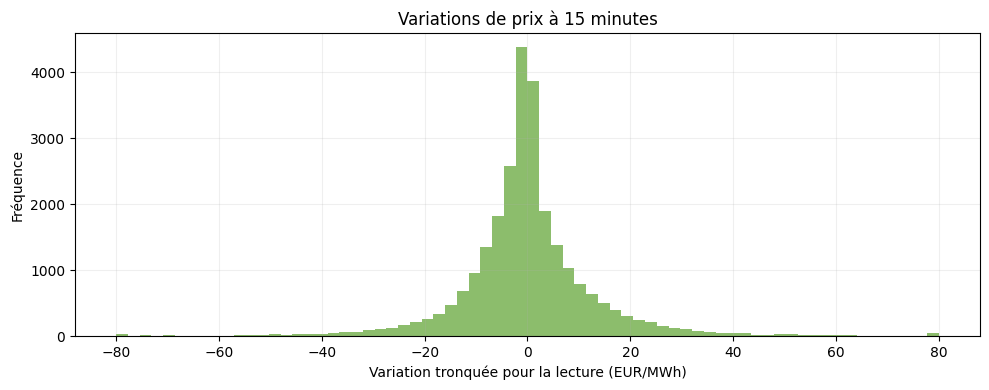

In [7]:
price_changes = native_prices['day_ahead_price'].diff()
ramp_summary = price_changes.abs().describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
).to_frame('absolute_15min_change_EUR_per_MWh')
display(ramp_summary.round(2))

ax = price_changes.clip(-80, 80).plot.hist(
    bins=70, figsize=(10, 4), color='#70AD47', alpha=0.8
)
ax.set(
    title='Variations de prix à 15 minutes',
    xlabel='Variation tronquée pour la lecture (EUR/MWh)',
    ylabel='Fréquence',
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Les variations entre deux quarts d'heure confirment que la résolution de 15 minutes apporte un signal que l'ancien historique horaire ne pouvait pas représenter.

## Isoler la forme journalière du niveau de prix

La *daily price shape* décrit la forme du prix à l'intérieur d'une journée. Ici, je l'ai définie par `prix du quart d'heure - prix moyen de la journée`. Une valeur de `+20 EUR/MWh` signifie donc que ce quart d'heure vaut 20 EUR/MWh de plus que la moyenne de sa propre journée. Cette définition additive reste lisible lorsque les prix sont négatifs ou proches de zéro, contrairement à un ratio.

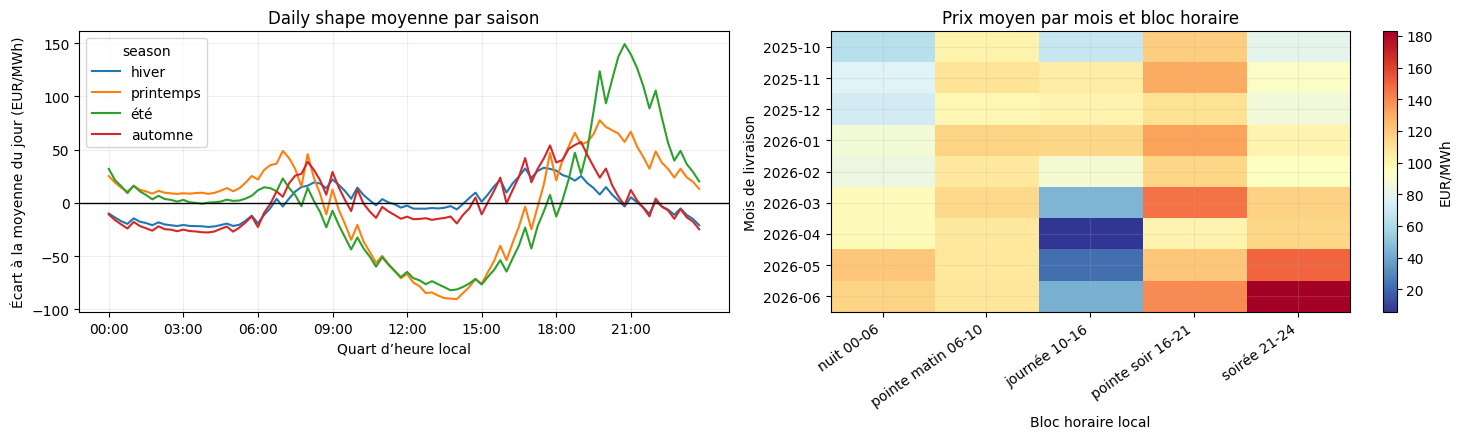

In [8]:
SEASON_ORDER = ['hiver', 'printemps', 'été', 'automne']
HOUR_BLOCK_ORDER = [
    'nuit 00-06', 'pointe matin 06-10', 'journée 10-16',
    'pointe soir 16-21', 'soirée 21-24',
]

def season_from_month(month):
    """Regroupe un numéro de mois dans une saison météorologique."""
    if month in (12, 1, 2):
        return 'hiver'
    if month in (3, 4, 5):
        return 'printemps'
    if month in (6, 7, 8):
        return 'été'
    return 'automne'

def hour_block_from_hour(hours):
    """Associe chaque heure locale au bloc utilisé dans les graphiques."""
    return pd.cut(
        hours, bins=[0, 6, 10, 16, 21, 24], right=False,
        labels=HOUR_BLOCK_ORDER, ordered=True,
    )

native_prices['season'] = pd.Categorical(
    native_prices['delivery_start_local'].dt.month.map(season_from_month),
    categories=SEASON_ORDER, ordered=True,
)
native_prices['hour_block'] = hour_block_from_hour(
    native_prices['delivery_start_local'].dt.hour
)
native_prices['daily_mean_price'] = native_prices.groupby(
    'delivery_date_local', observed=True
)['day_ahead_price'].transform('mean')
native_prices['daily_shape_eur_per_mwh'] = (
    native_prices['day_ahead_price'] - native_prices['daily_mean_price']
)

shape_by_season = native_prices.groupby(
    ['local_quarter', 'season'], observed=True
)['daily_shape_eur_per_mwh'].mean().unstack()
block_by_month = native_prices.groupby(
    ['delivery_month', 'hour_block'], observed=True
)['day_ahead_price'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
shape_by_season.plot(ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set(
    title='Daily shape moyenne par saison',
    xlabel='Quart d’heure local', ylabel='Écart à la moyenne du jour (EUR/MWh)',
)
axes[0].set_xticks(range(0, 96, 12), [f'{hour:02d}:00' for hour in range(0, 24, 3)])

image = axes[1].imshow(block_by_month, aspect='auto', cmap='RdYlBu_r')
axes[1].set(
    title='Prix moyen par mois et bloc horaire',
    xlabel='Bloc horaire local', ylabel='Mois de livraison',
)
axes[1].set_xticks(range(len(block_by_month.columns)), block_by_month.columns, rotation=35, ha='right')
axes[1].set_yticks(range(len(block_by_month.index)), block_by_month.index)
fig.colorbar(image, ax=axes[1], label='EUR/MWh')
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

La forme journalière dépend de la saison. Le creux de mi-journée devient plus visible avec le solaire, tandis que la pointe du soir reste structurante. Le modèle aura donc besoin à la fois des variables calendaires et des variables de système ou de météo.

## Comparer DE-LU aux marchés voisins

Les prix de l'Autriche, de la Belgique, de la Tchéquie, de la France, des Pays-Bas et de la Pologne servent ici à comprendre le couplage régional. Les corrélations contemporaines et les spreads de la journée D sont descriptifs : ils ne seront pas utilisés tels quels à 10:30 en D-1, puisque ces prix ne sont pas encore issus du clearing.

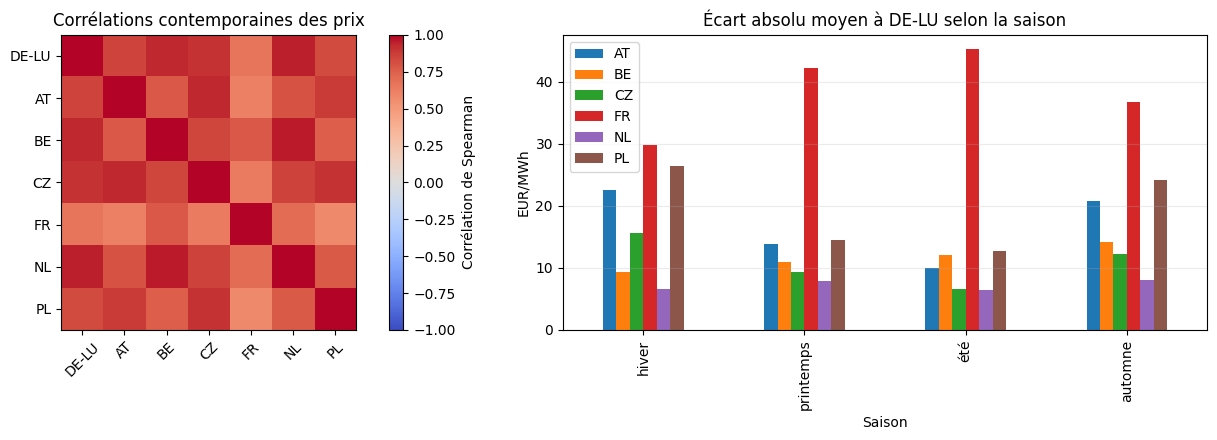

,correlation_with_de_lu
NL,0.951
BE,0.930
CZ,0.903
AT,0.845
PL,0.825
FR,0.661


In [9]:
neighbor_prices = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'market_15m' / 'de_lu_neighbor_day_ahead_prices.parquet'
)
neighbor_prices['delivery_start_utc'] = pd.to_datetime(
    neighbor_prices['delivery_start_utc'], utc=True
)
neighbor_analysis = native_prices[[
    'delivery_start_utc', 'day_ahead_price', 'season', 'hour_block'
]].merge(neighbor_prices, on='delivery_start_utc', how='inner')

zone_names = {
    'day_ahead_price': 'DE-LU',
    'neighbor_price_at_eur_per_mwh': 'AT',
    'neighbor_price_be_eur_per_mwh': 'BE',
    'neighbor_price_cz_eur_per_mwh': 'CZ',
    'neighbor_price_fr_eur_per_mwh': 'FR',
    'neighbor_price_nl_eur_per_mwh': 'NL',
    'neighbor_price_pl_eur_per_mwh': 'PL',
}
market_prices = neighbor_analysis[list(zone_names)].rename(columns=zone_names)
price_correlations = market_prices.corr(method='spearman')

spread_columns = {}
for source_column, zone in list(zone_names.items())[1:]:
    spread_column = f'absolute_spread_{zone}'
    neighbor_analysis[spread_column] = (
        neighbor_analysis[source_column] - neighbor_analysis['day_ahead_price']
    ).abs()
    spread_columns[spread_column] = zone
seasonal_spreads = neighbor_analysis.groupby(
    'season', observed=True
)[list(spread_columns)].mean().rename(columns=spread_columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
image = axes[0].imshow(price_correlations, vmin=-1, vmax=1, cmap='coolwarm')
axes[0].set(title='Corrélations contemporaines des prix')
axes[0].set_xticks(range(len(price_correlations)), price_correlations.columns, rotation=45)
axes[0].set_yticks(range(len(price_correlations)), price_correlations.index)
fig.colorbar(image, ax=axes[0], label='Corrélation de Spearman')
seasonal_spreads.plot.bar(ax=axes[1])
axes[1].set(
    title='Écart absolu moyen à DE-LU selon la saison',
    xlabel='Saison', ylabel='EUR/MWh',
)
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

display(price_correlations['DE-LU'].drop('DE-LU').sort_values(ascending=False).to_frame('correlation_with_de_lu').round(3))

Les marchés voisins évoluent souvent dans la même direction que DE-LU, sans avoir systématiquement le même niveau de prix. Le graphique des spreads montre justement cette différence. Pour la prévision, seuls les prix voisins retardés sont utilisables : les prix contemporains du jour de livraison ne sont pas encore connus au cutoff.

## Regarder comment les drivers changent avec le calendrier

Les tables préparées permettent de rapprocher le prix, la charge, la génération nationale, la météo régionale et les données JAO. Les moyennes météo ci-dessous résument les sept points allemands.

`D2CF` signifie *Two-Days Ahead Congestion Forecast*. Les champs JAO décrivent les hypothèses du modèle de réseau commun : charge verticale, génération et position nette. Ils servent ici à l'analyse du marché. Les publications JAO D2CF connues à 10:30 en D-1 font partie des features du modèle opérationnel (charge verticale, génération D2CF, positions nettes et limites transfrontalières).

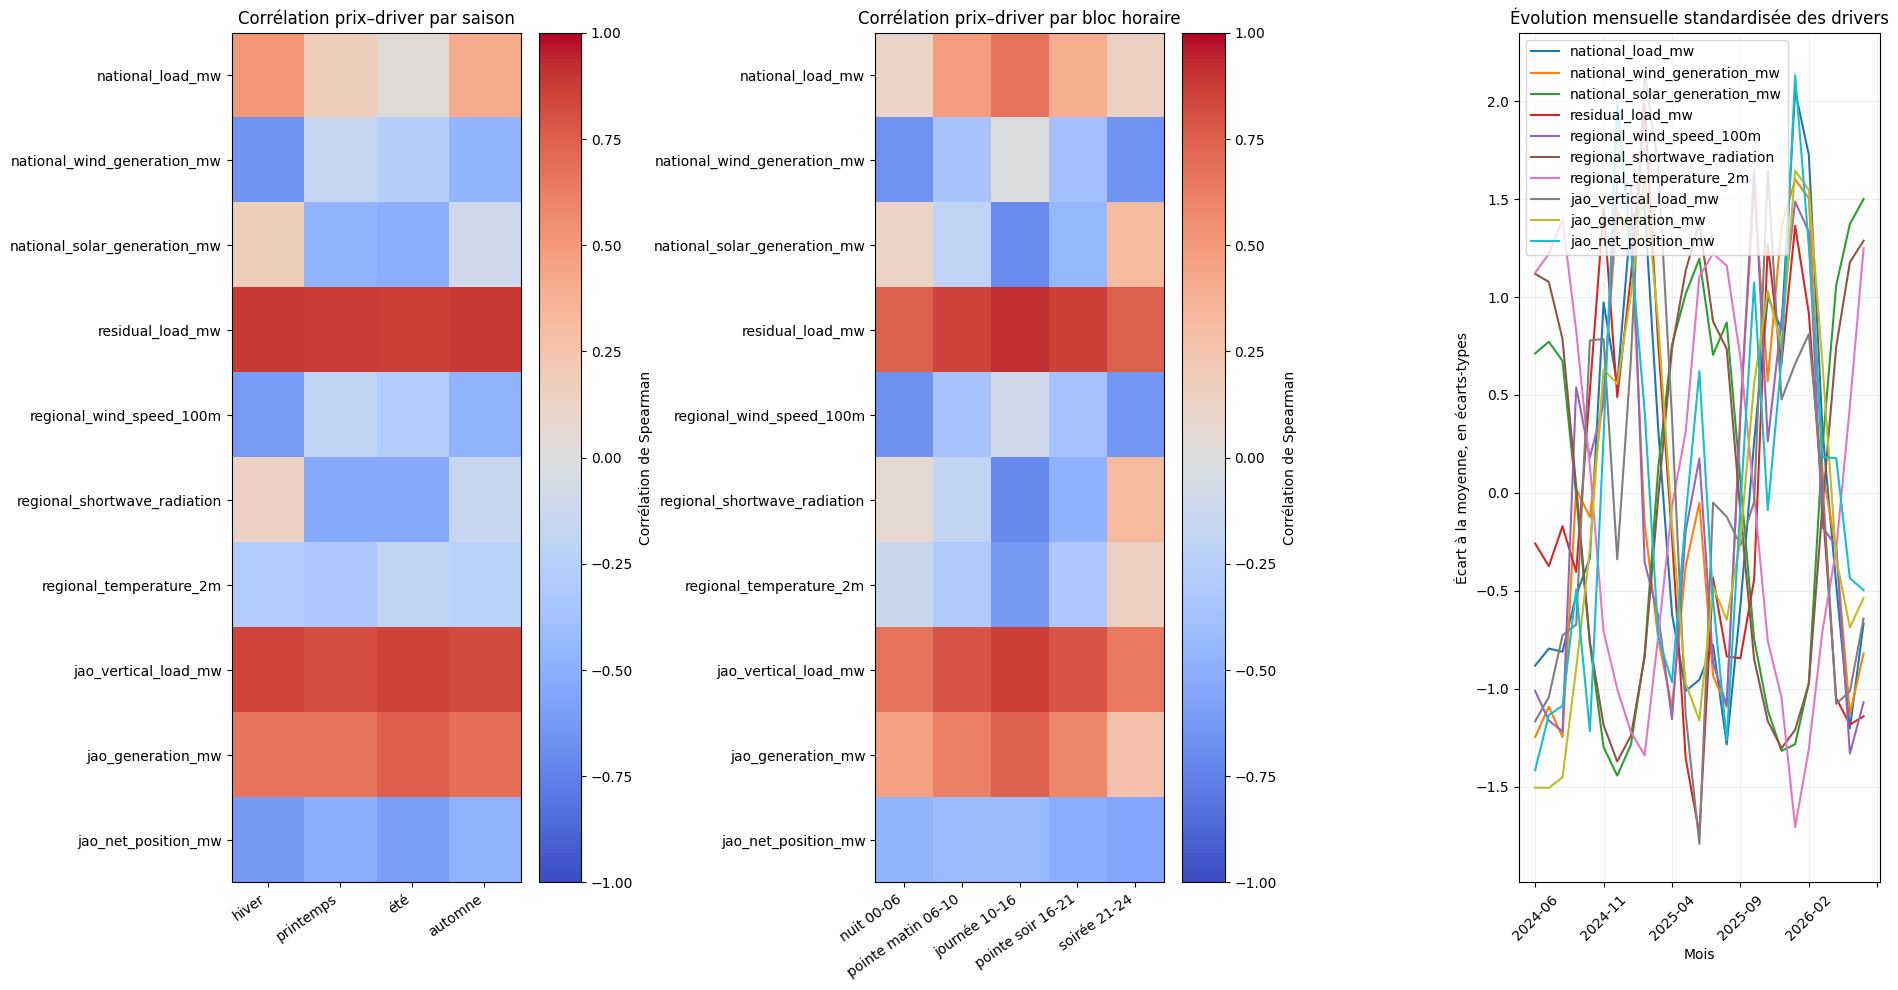

In [10]:
aligned_data = model_data.loc[
    model_data['delivery_start_local'] < TEST_START
].copy()

system_actual = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'market_15m' / 'de_lu_system_actual_15m.parquet'
)
aligned_data = aligned_data.merge(
    system_actual.drop(columns=['national_load_mw', 'source', 'value_type']),
    on='delivery_start_utc', how='left'
)
aligned_data['national_wind_generation_mw'] = (
    aligned_data['national_wind_onshore_generation_mw']
    + aligned_data['national_wind_offshore_generation_mw']
)

weather_suffixes = {
    'regional_wind_speed_100m': '_wind_speed_100m',
    'regional_shortwave_radiation': '_shortwave_radiation',
    'regional_temperature_2m': '_temperature_2m',
}
for new_column, suffix in weather_suffixes.items():
    source_columns = [column for column in aligned_data if column.endswith(suffix)]
    aligned_data[new_column] = aligned_data[source_columns].mean(axis=1)

aligned_data['season'] = pd.Categorical(
    aligned_data['delivery_start_local'].dt.month.map(season_from_month),
    categories=SEASON_ORDER, ordered=True,
)
aligned_data['hour_block'] = hour_block_from_hour(
    aligned_data['delivery_start_local'].dt.hour
)
aligned_data['delivery_month'] = aligned_data['delivery_start_local'].dt.strftime('%Y-%m')

driver_columns = [
    'national_load_mw', 'national_wind_generation_mw',
    'national_solar_generation_mw', 'residual_load_mw',
    'regional_wind_speed_100m',
    'regional_shortwave_radiation', 'regional_temperature_2m',
    'jao_vertical_load_mw', 'jao_generation_mw', 'jao_net_position_mw',
]
season_correlations = pd.DataFrame({
    season: group[['day_ahead_price', *driver_columns]].corr(
        method='spearman'
    )['day_ahead_price'].drop('day_ahead_price')
    for season, group in aligned_data.groupby('season', observed=True)
})
block_correlations = pd.DataFrame({
    block: group[['day_ahead_price', *driver_columns]].corr(
        method='spearman'
    )['day_ahead_price'].drop('day_ahead_price')
    for block, group in aligned_data.groupby('hour_block', observed=True)
})

monthly_drivers = aligned_data.groupby('delivery_month')[driver_columns].mean()
standardized_monthly_drivers = (
    monthly_drivers - monthly_drivers.mean()
) / monthly_drivers.std()

fig, axes = plt.subplots(1, 3, figsize=(19, 10))
for axis, table, title in [
    (axes[0], season_correlations, 'Corrélation prix–driver par saison'),
    (axes[1], block_correlations, 'Corrélation prix–driver par bloc horaire'),
]:
    image = axis.imshow(table, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    axis.set_title(title)
    axis.set_xticks(range(len(table.columns)), table.columns, rotation=35, ha='right')
    axis.set_yticks(range(len(table.index)), table.index)
    fig.colorbar(image, ax=axis, label='Corrélation de Spearman')
standardized_monthly_drivers.plot(ax=axes[2])
axes[2].set(
    title='Évolution mensuelle standardisée des drivers',
    xlabel='Mois', ylabel='Écart à la moyenne, en écarts-types',
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.2)
plt.tight_layout()
plt.show()

Les relations varient selon la saison et le bloc horaire. Dans cet échantillon, le residual load et les variables JAO de charge verticale et de génération présentent les associations les plus fortes avec le prix, tandis que la production éolienne nationale et la vitesse du vent sont généralement négativement associées au prix. Le solaire national, le rayonnement régional et la température apportent une lecture complémentaire, dont l'intensité dépend du moment de la journée.

Ces corrélations sont descriptives et ne prouvent pas une causalité. Les séries réalisées et les variables JAO historiques servent ici à comprendre le marché.

## Préparer les variables disponibles avant le clearing

Les prix voisins contemporains vus plus haut servent uniquement à comprendre le marché. Ils ne sont pas connus à notre cutoff de D-1. La table suivante vérifie donc les variables qui alimenteront réellement le modèle : calendrier, historique DE-LU, charge, météo régionale et prix voisins retardés.

In [11]:
feature_names = de_lu_operational_feature_columns(model_data)
pre_test_model_data = model_data.loc[
    model_data['delivery_start_local'] < TEST_START
].copy()
feature_availability = pre_test_model_data[feature_names].notna().mean().mul(100)
feature_availability.to_frame('available_rows_percent').round(2)

,available_rows_percent
local_time_sin,100.00
local_time_cos,100.00
day_of_week_sin,100.00
day_of_week_cos,100.00
day_of_year_sin,100.00
...,...
neighbor_fr_price_lag_7d,99.06
neighbor_nl_price_lag_1d,99.87
neighbor_nl_price_lag_7d,99.06
neighbor_pl_price_lag_1d,99.87


Les valeurs manquantes se concentrent au début de l'historique, avant que les lags et les fenêtres de 28 jours soient complets. Elles seront retirées après la séparation temporelle, pas remplacées par des informations futures. Les publications JAO et les prix voisins retardés font partie des variables du modèle.

## Séparation temporelle retenue

In [12]:
local_delivery_time = model_data['delivery_start_local']
split_summary = pd.DataFrame({
    'period': [
        '14/06/2024 → 30/09/2025',
        '01/10/2025 → 30/04/2026',
        '01/05/2026 → 30/06/2026',
        '01/07/2026 → 31/08/2026',
    ],
    'role': [
        'historique auxiliaire',
        'entraînement natif',
        'validation commune',
        'test final fermé',
    ],
    'rows': [
        (local_delivery_time < NATIVE_15M_START).sum(),
        ((local_delivery_time >= NATIVE_15M_START) & (local_delivery_time < VALIDATION_START)).sum(),
        ((local_delivery_time >= VALIDATION_START) & (local_delivery_time < TEST_START)).sum(),
        (local_delivery_time >= TEST_START).sum(),
    ],
    'row_weight_during_fit': [0.25, 1.0, pd.NA, pd.NA],
})
split_summary

,period,role,rows,row_weight_during_fit
0,14/06/2024 → 30/09/2025,historique auxiliaire,45408,0.25
1,01/10/2025 → 30/04/2026,entraînement natif,20352,1.0
2,01/05/2026 → 30/06/2026,validation commune,5856,<NA>
3,01/07/2026 → 31/08/2026,test final fermé,5952,<NA>


Deux entraînements seront comparés sur la même validation puis, une seule fois, sur le même test : le premier utilisera uniquement le régime natif ; le second ajoutera l'ancien historique avec un poids `0,25`. La baseline unique sera la persistance D-7.
